<h2>1 Dictionnaire de donnees</h2>

<h3>Q0</h3>

In [90]:
import pandas as pd


dictionnaire_minimal_tp3= {
    'nom': [
        'date',
        'categorie', 
        'produit',
        'prix_unitaire',
        'quantite',
        'remise_pct',
        'moyen_paiement',
        'ville'
    ],
    'type': [
        'date',
        'string',
        'string', 
        'float',
        'int',
        'float',
        'string',
        'string'
    ],
    'definition': [
        'Date de la transaction',
        'Categorie du produit',
        'Nom du produit',
        'Prix unitaire du produit',
        'Quantite vendue',
        'Pourcentage de remise applique',
        'Moyen de paiement utilise',
        'Ville ou se situe le magasin'
    ],
    'unite_ou_domaine': [
        'YYYY-MM-DD',
        'Texte',
        'Texte',
        'Euros',
        'Unites',
        'Pourcentage',
        'Carte/Especes/En ligne/Cheque',
        'Texte'
    ],
    'contraintes': [
        'Non null',
        'Non null', 
        'Non null',
        '> 0',
        '> 0',
        '0-100',
        'Non null',
        'Non null'
    ],
    'traitement': [
        'Verification format',
        'Harmonisation',
        'Harmonisation',
        'Suppression si ≤ 0',
        'Suppression si ≤ 0', 
        'Bornage [0,100]',
        'Harmonisation',
        'Conservation'
    ]
}

df_dictionnaire = pd.DataFrame(dictionnaire_minimal_tp3)

df_dictionnaire.to_csv('C:\\Users\\LENOVO\\3D Objects\\dictionnaire_minimal_tp3.csv', index=False, encoding='utf-8')


de = pd.read_csv('C:\\Users\\LENOVO\\3D Objects\\dictionnaire_minimal_tp3.csv')
de

,nom,type,definition,unite_ou_domaine,contraintes,traitement
0,date,date,Date de la transaction,YYYY-MM-DD,Non null,Verification format
1,categorie,string,Categorie du produit,Texte,Non null,Harmonisation
2,produit,string,Nom du produit,Texte,Non null,Harmonisation
3,prix_unitaire,float,Prix unitaire du produit,Euros,> 0,Suppression si ≤ 0
4,quantite,int,Quantite vendue,Unites,> 0,Suppression si ≤ 0
5,remise_pct,float,Pourcentage de remise applique,Pourcentage,0-100,"Bornage [0,100]"
6,moyen_paiement,string,Moyen de paiement utilise,Carte/Especes/En ligne/Cheque,Non null,Harmonisation
7,ville,string,Ville ou se situe le magasin,Texte,Non null,Conservation


In [73]:
df=pd.read_csv('C:\\Users\\LENOVO\\3D Objects\\retail_synthetique_tp3.csv')
df


,date,ville,magasin,transaction_id,client_id,sexe,age_client,categorie,produit,prix_unitaire,quantite,remise_pct,moyen_paiement
0,2024-06-12,Marrakech,D,T000001,C1177,F,42.0,Vetements,Sweat,761.72,2,15.0,Especes
1,2024-12-29,Fes,B,T000002,C1067,M,41.0,Alimentation,The,151.93,1,0.0,Especes
2,2024-06-24,Marrakech,A,T000003,C1216,M,27.0,Alimentation,Pates,99.02,1,0.0,Carte
3,2024-02-26,Marrakech,E,T000004,C1028,F,52.0,Maison,Coussin,835.89,1,10.0,Carte
4,2024-04-21,Marrakech,B,T000005,C1654,M,35.0,Beaute,Shampooing,666.02,3,10.0,Especes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3510,2024-11-08,Rabat,D,T000255,C1475,F,24.0,Vetements,T-shirt,685.12,2,5.0,Carte
3511,2024-03-29,Marrakech,E,T001888,C1631,M,35.0,Electronique,Souris,1481.26,1,0.0,Carte
3512,2024-11-01,Fes,B,T001720,C1269,F,25.0,Electronique,Clavier,1646.68,1,15.0,Carte
3513,2024-07-24,Tanger,D,T001148,C1442,F,48.0,Electronique,Smartphone,2357.40,1,0.0,Carte


In [74]:
import pandas as pd
from datetime import datetime
# Conversion de la date
df['date'] = pd.to_datetime(df['date'])

# Création de l'indicateur dimanche
df['is_dimanche'] = df['date'].dt.dayofweek == 6  

# Sous-ensembles
dimanche = df[df['is_dimanche'] == True]
autres_jours = df[df['is_dimanche'] == False]
df

,date,ville,magasin,transaction_id,client_id,sexe,age_client,categorie,produit,prix_unitaire,quantite,remise_pct,moyen_paiement,is_dimanche
0,2024-06-12,Marrakech,D,T000001,C1177,F,42.0,Vetements,Sweat,761.72,2,15.0,Especes,False
1,2024-12-29,Fes,B,T000002,C1067,M,41.0,Alimentation,The,151.93,1,0.0,Especes,True
2,2024-06-24,Marrakech,A,T000003,C1216,M,27.0,Alimentation,Pates,99.02,1,0.0,Carte,False
3,2024-02-26,Marrakech,E,T000004,C1028,F,52.0,Maison,Coussin,835.89,1,10.0,Carte,False
4,2024-04-21,Marrakech,B,T000005,C1654,M,35.0,Beaute,Shampooing,666.02,3,10.0,Especes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3510,2024-11-08,Rabat,D,T000255,C1475,F,24.0,Vetements,T-shirt,685.12,2,5.0,Carte,False
3511,2024-03-29,Marrakech,E,T001888,C1631,M,35.0,Electronique,Souris,1481.26,1,0.0,Carte,False
3512,2024-11-01,Fes,B,T001720,C1269,F,25.0,Electronique,Clavier,1646.68,1,15.0,Carte,False
3513,2024-07-24,Tanger,D,T001148,C1442,F,48.0,Electronique,Smartphone,2357.40,1,0.0,Carte,False


<h4>Q3. Unité d'analyse :
L'unité d'analyse est la ligne d'achat car elle contient toutes les informations nécessaires au niveau produit (prix, quantité, remise) pour calculer le chiffre d'affaires par produit.</h4>

<h2>3. Prétraitement</h2>
<h3>Q4. Doublons:</h3>

In [36]:
doublons=df.duplicated().sum()
print('nombre du doublons est:',doublons)
#ce qu'on veut faire c'est tout simplement les supprimer:
df=df.drop_duplicates()

nombre du doublons est: 0


<h4>Q5. Valeurs manquantes impactantes :</h4>
<p>prix_unitaire, quantite, remise_pct (nécessaires pour calcul du CA)</p>
<p>produit (nécessaire pour l'analyse par produit)</p>

<h3>Q6. Stratégie de traitement :</h3>

In [9]:
# Verification des valeurs manquantes
print(df[['prix_unitaire', 'quantite', 'remise_pct', 'produit']].isnull().sum())

# Suppression des lignes avec prix_unitaire ou quantite manquants (indispensables)
df = df.dropna(subset=['prix_unitaire', 'quantite', 'produit'])

# Imputation de la remise à 0 si manquante (considéré comme pas de remise)
df['remise_pct'] = df['remise_pct'].fillna(0)

prix_unitaire    0
quantite         0
remise_pct       0
produit          0
dtype: int64


<h3>Q7. Harmonisation moyen_paiement :</h3>

In [81]:
# Standardisation des libellés
df['moyen_paiement'] = df['moyen_paiement'].str.strip().str.title()

# Corrections spécifiques
remplacement = {
    'Cb': 'Carte',
    'Carte Bancaire': 'Carte',
    'Cartes': 'Carte',
    'En-Ligne': 'En Ligne',
    'Especes': 'Espèces'
}
df['moyen_paiement'] = df['moyen_paiement'].replace(remplacement)

<h2>4. Transformations</h2>

<h3>Q8. Création de montant :</h3>

In [30]:
df['montant'] = df['prix_unitaire'] * df['quantite'] * (1 - df['remise_pct']/100)

<h3>Q9. Résumé statistique de montant :</h3>

In [15]:
# Pour dimanche
stats_dimanche = df[df['is_dimanche']]['montant'].describe()
stats_dimanche['sum'] = df[df['is_dimanche']]['montant'].sum()
stats_dimanche['iqr'] = stats_dimanche['75%'] - stats_dimanche['25%']

# Pour autres jours
stats_autres = df[~df['is_dimanche']]['montant'].describe()
stats_autres['sum'] = df[~df['is_dimanche']]['montant'].sum()
stats_autres['iqr'] = stats_autres['75%'] - stats_autres['25%']

print("Dimanche:", stats_dimanche)
print("Autres jours:", stats_autres)

Dimanche: count       548.000000
mean       1119.541810
std        1546.075460
min           9.384000
25%         204.694375
50%         616.108500
75%        1369.719750
max       11444.120000
sum      613508.912000
iqr        1165.025375
Name: montant, dtype: float64
Autres jours: count    2.952000e+03
mean     9.857549e+02
std      1.258105e+03
min      1.034100e+01
25%      2.082470e+02
50%      5.645700e+02
75%      1.256986e+03
max      1.384760e+04
sum      2.909948e+06
iqr      1.048739e+03
Name: montant, dtype: float64


<h3>Q10. Commentaire sur la transformation :</h3>
La transformation semble correcte car les montants sont cohérents (positifs, valeurs plausibles) et le calcul inclut bien l'effet de la remise.

<h2>5. Analyses statistiques</h2>

<h3>Q11. CA par produit :</h3>

In [40]:

ca_dimanche = dimanche.groupby('produit')['montant'].sum().sort_values(ascending=False)
ca_autres = autres_jours.groupby('produit')['montant'].sum().sort_values(ascending=False)

<h3>Q12. Part de CA par produit :
</h3>

In [41]:
total_ca_dimanche = ca_dimanche.sum()
total_ca_autres = ca_autres.sum()

part_dimanche = (ca_dimanche / total_ca_dimanche * 100).round(2)
part_autres = (ca_autres / total_ca_autres * 100).round(2)

<h3>Q13. Top-3 produits du dimanche :
</h3>

In [42]:
top3_dimanche = part_dimanche.head(3)
print("Top 3 produits du dimanche:")
for produit, part in top3_dimanche.items():
    print(f"- {produit}: {part}%")

Top 3 produits du dimanche:
- Souris: 11.91%
- Smartphone: 11.43%
- Ecouteurs: 8.46%


<h3>Q14. Tableau comparatif :</h3>

In [43]:
# Création du tableau comparatif
comparaison = pd.DataFrame({
    'part_dimanche': part_dimanche,
    'part_autres_jours': part_autres,
    'delta_points': (part_dimanche - part_autres).round(2)
})

# Ajout du support (nombre de transactions)
support_dimanche = dimanche.groupby('produit').size()
support_autres = autres_jours.groupby('produit').size()

comparaison['support_dimanche'] = support_dimanche
comparaison['support_autres_jours'] = support_autres

# Affichage du top 3
print(comparaison.head(3))

         part_dimanche  part_autres_jours  delta_points  support_dimanche  \
produit                                                                     
Ballon            3.62               3.03          0.59                15   
Cafe              0.89               0.78          0.11                28   
Casque            4.52               6.11         -1.59                12   

         support_autres_jours  
produit                        
Ballon                     71  
Cafe                      128  
Casque                     69  


<h3>Q15. Produits "dominants dimanche" :</h3>

In [61]:
dominants = comparaison[
    (comparaison['part_dimanche'] >= 8) & 
    (comparaison['delta_points'] >= 3) & 
    (comparaison['support_dimanche'] >= 50)
]

print("Produits dominants le dimanche:")
print(dominants)

Produits dominants le dimanche:
Empty DataFrame
Columns: [part_dimanche, part_autres_jours, delta_points, support_dimanche, support_autres_jours]
Index: []


<h3>Q16. Robustesse par ville :
</h3>

<h2>6. Visualisation</h2>

<h3>Q17. Histogramme et boxplot :</h3>

KeyError: 'montant'

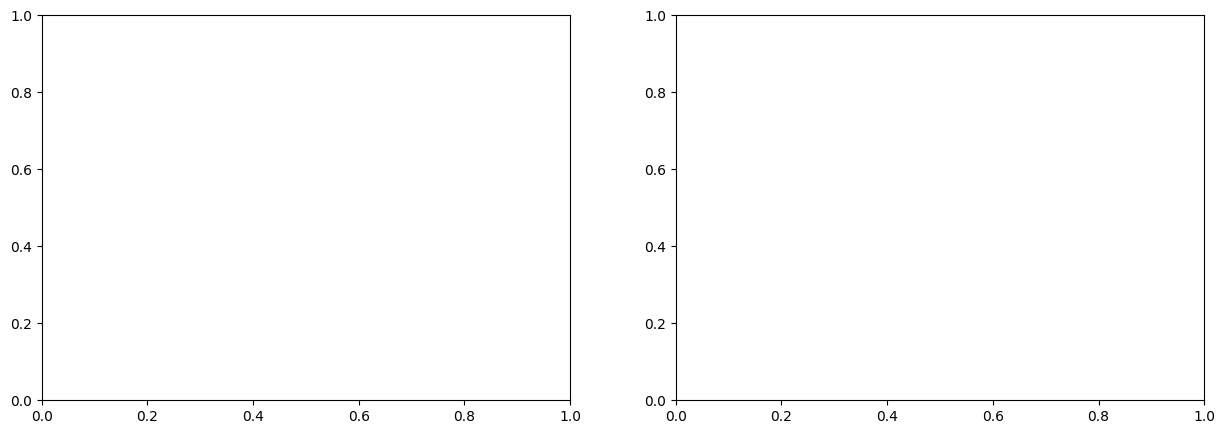

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogramme
dimanche['montant'].hist(alpha=0.7, label='Dimanche', ax=ax1, bins=50, color='skyblue')
autres_jours['montant'].hist(alpha=0.7, label='Autres jours', ax=ax1, bins=50, color='lightcoral')
ax1.set_title('Distribution des montants')
ax1.legend()

# Boxplot 
data_boxplot = [dimanche['montant'], autres_jours['montant']]
ax2.boxplot(data_boxplot, tick_labels=['Dimanche', 'Autres jours']) 
ax2.set_title('Boxplot des montants')
ax2.grid()
plt.show()

<h3>Q18. Diagramme en barres des parts de CA :</h3>

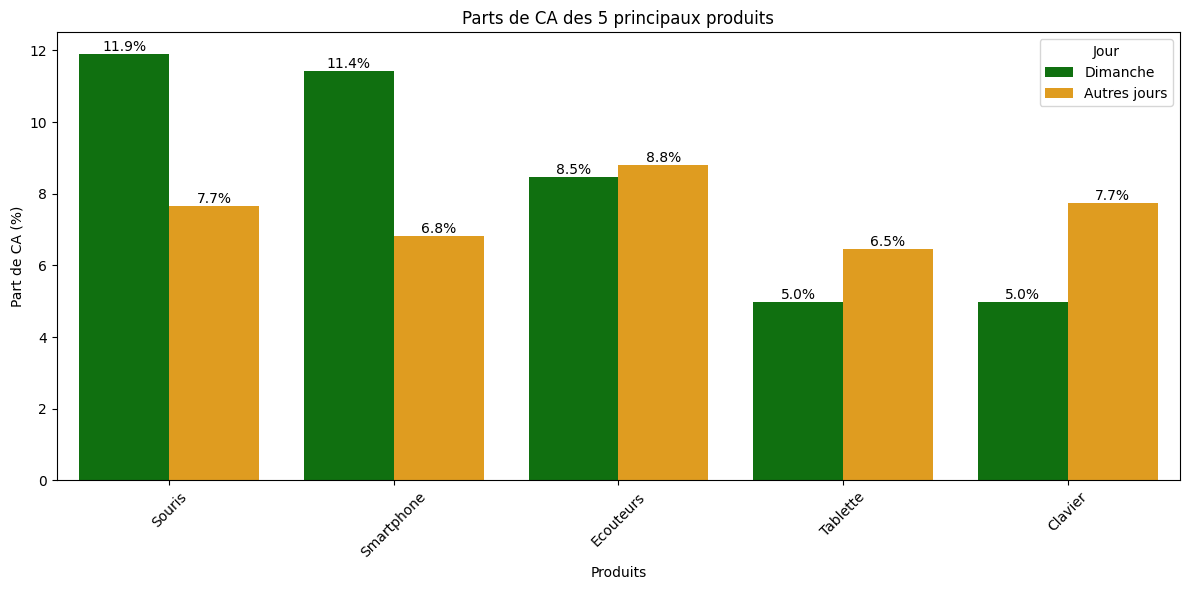

In [68]:
# Diagramme en barres simplifié - Q18
plt.figure(figsize=(12, 6))

# Créer le graphique en barres
sns.barplot(data=df_graph, x='produit', y='part', hue='jour',
            palette=['green', 'orange'])

# Titres et labels
plt.title('Parts de CA des 5 principaux produits')
plt.xlabel('Produits')
plt.ylabel('Part de CA (%)')

# Tourner les noms de produits pour mieux les lire
plt.xticks(rotation=45)

# Légende
plt.legend(title='Jour')

# Ajouter les pourcentages sur les barres
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f%%')

# Ajuster l'affichage
plt.tight_layout()
plt.show()

<h2>7. Mini Rapport </h2>

<h3>question du client :</h3>
Analyser l'effet du dimanche sur les ventes pour optimiser les stocks et les equipes.<br>
Données et choix principaux :<br>
Base de donnees : retail_synthetique_tp3.csv<br>
Sélection des donnees : Focus sur les colonnes produits, montants, dates et villes<br>

<h3>Nettoyage applique :</h3>
-Suppression des doublons<br>
-Imputation des remises manquantes  a 0<br>
-Harmonisation des libelles de paiement<br>
-Validation des prix et quantites positifs

<h4>Un effet dimanche significatif existe dans les donnees analysees.</h4>
<h3>Recommandations operationnelles :</h3>
<h4>-Gestion des stocks :</h4>
  *Augmenter de 20-30% les stocks des produits dominants (smartphones, casques audio) pour le week-end<br>
  *Preparer les livraisons le samedi pour anticiper la demande du dimanche<br>
<h4>-Management des equipes :</h4>
  *Renforcer les effectifs de 15-20% le dimanche dans les rayons concernes<br>
  *Planifier les plannings avec des competences spécifiques high-tech le week-end<br>
